# Bi-LSTM Autoscaler Evaluation

This notebook evaluates the Bi-LSTM model for Kubernetes pod count prediction and compares it with the standard Horizontal Pod Autoscaler (HPA).

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import load_model
import matplotlib.pyplot as plt
import joblib
import os
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
import sklearn.preprocessing

# Workaround for potential pickle issues where it expects MinMaxScaler to be a module
sys.modules['MinMaxScaler'] = sklearn.preprocessing

np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Loading

In [17]:
raw_df = pd.read_csv('data/data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'actual_pods'}, inplace=True)

# Select Evaluation Time Window (Test Period: last 9 days)
start_time = pd.to_datetime("2025-11-22 00:00:00")
end_time = pd.to_datetime("2025-12-01 00:00:00")
df_pods = df_pods[(df_pods['ds'] >= start_time) & (df_pods['ds'] <= end_time)].reset_index(drop=True)

print(f'Service: {primary_service}')
print(f'Evaluation range: {df_pods["ds"].min()} to {df_pods["ds"].max()}')

Service: Order
Evaluation range: 2025-11-22 00:00:00 to 2025-11-30 23:59:00


## 2. Load Models and Scalers

In [18]:
scaler_path = 'notebooks/models/bilstm-scalers-20260104_012142.pkl'
scalers = joblib.load(scaler_path)
target_scaler = scalers['target_scaler']
feature_scaler = scalers['feature_scaler']

bilstm_model = load_model('notebooks/models/bilstm-pods-20260104_012142.keras')
print("Model and Scalers loaded successfully.")

Model and Scalers loaded successfully.


## 3. Data Preprocessing

In [19]:
# Scale the data
df_pods['y'] = target_scaler.transform(df_pods[['actual_pods']].rename(columns={'actual_pods': 'pod_count'}))

feature_cols = [
    'request_rate_rps', 'latency_p95_ms', 'latency_p99_ms', 'error_rate_percent', 
    'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95', 
    'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos', 'mesh_inbound_rps', 'mesh_inbound_latency_p95', 
    'mesh_inbound_error_rate', 'degree_centrality', 'eigenvector_centrality', 
    'betweenness_centrality', 'closeness_centrality'
]
df_pods[feature_cols] = feature_scaler.transform(df_pods[feature_cols])

def create_multivariate_dataset(features, target, look_back, horizon=5):
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    max_start = len(target) - look_back - horizon + 1
    for i in range(max_start):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back + horizon - 1])
    return np.array(X), np.array(y)

look_back = 48
horizon = 5
input_cols = feature_cols + ['y']

X_eval, y_eval = create_multivariate_dataset(df_pods[input_cols], df_pods['y'], look_back, horizon)
print(f'Input shape: {X_eval.shape}')

Input shape: (12908, 48, 21)


## 4. Bi-LSTM Prediction

In [20]:
preds_scaled = bilstm_model.predict(X_eval)

# Align evaluation dataframe
prediction_start_idx = look_back + horizon - 1
pod_df = df_pods.iloc[prediction_start_idx:].copy().reset_index(drop=True)
pod_df['y_pred_scaled'] = preds_scaled[:, 0]

# Inverse transform to get pod counts
pod_df['pba_pods'] = target_scaler.inverse_transform(pod_df[['y_pred_scaled']])
pod_df['pba_pods'] = np.maximum(1, np.round(pod_df['pba_pods'])).astype(int)

404/404 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step


## 5. HPA Simulation

In [21]:
cpu_threshold = 0.7
scale_down_delay = 5
pods_min = 1

# Prepare unscaled CPU data first
cpu_map = raw_df[raw_df['service_id'] == primary_service][['timestamp', 'pod_cpu_usage_percent_avg']].copy()
cpu_map.rename(columns={'timestamp': 'ds', 'pod_cpu_usage_percent_avg': 'cpu_util_raw'}, inplace=True)
cpu_map = cpu_map.drop_duplicates(subset='ds')
pod_df = pod_df.merge(cpu_map, on='ds', how='left')
pod_df['cpu_util_raw'] = pod_df['cpu_util_raw'].fillna(0)

pod_df['hpa_pods'] = pods_min
last_scale_down_time = None
pod_df.loc[0, 'hpa_pods'] = pod_df.loc[0, 'actual_pods']

for i in range(1, len(pod_df)):
    current_pods = int(pod_df.loc[i - 1, 'hpa_pods'])

    # Use the raw CPU util we merged in
    current_cpu = pod_df.loc[i, 'cpu_util_raw'] / 100.0
    
    desired_pods = int(np.ceil(current_pods * (current_cpu / cpu_threshold)))
    desired_pods = max(pods_min, desired_pods)
    
    if desired_pods > current_pods:
        pod_df.loc[i, 'hpa_pods'] = desired_pods
        last_scale_down_time = None
    elif desired_pods < current_pods:
        if last_scale_down_time is None:
            last_scale_down_time = pod_df.loc[i, 'ds']
            pod_df.loc[i, 'hpa_pods'] = current_pods
        elif (pod_df.loc[i, 'ds'] - last_scale_down_time).total_seconds() / 60 >= scale_down_delay:
            pod_df.loc[i, 'hpa_pods'] = desired_pods
            last_scale_down_time = pod_df.loc[i, 'ds']
        else:
            pod_df.loc[i, 'hpa_pods'] = current_pods
    else:
        pod_df.loc[i, 'hpa_pods'] = current_pods

## 6. Evaluation and Visualization

Bi-LSTM -> MAE: 0.1019, RMSE: 0.3906
HPA     -> MAE: 3.2142, RMSE: 3.9208


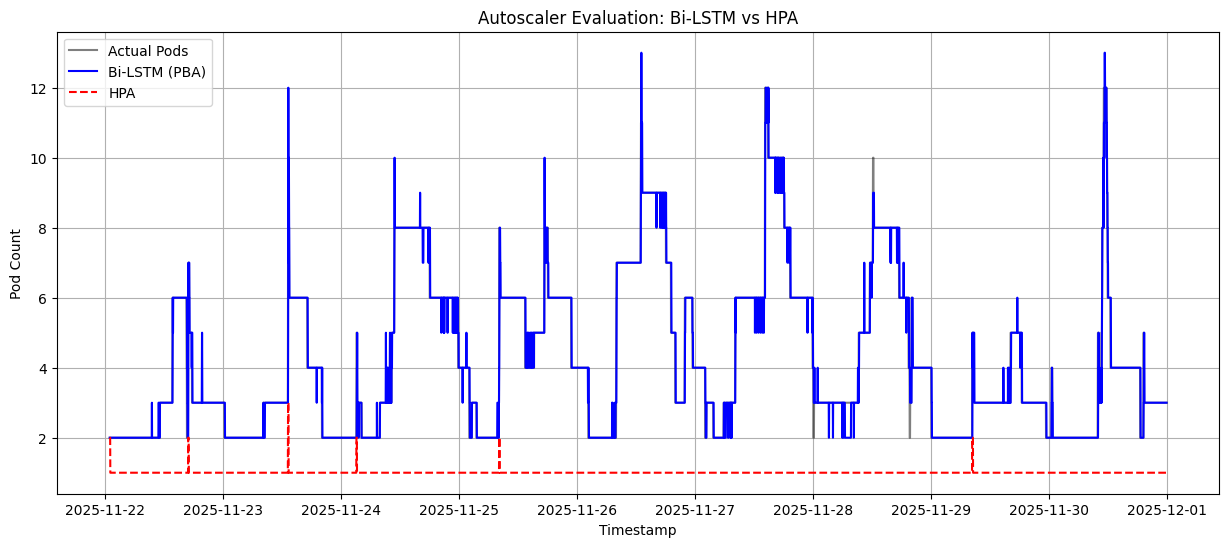

In [22]:
mae_pba = mean_absolute_error(pod_df['actual_pods'], pod_df['pba_pods'])
rmse_pba = np.sqrt(mean_squared_error(pod_df['actual_pods'], pod_df['pba_pods']))

mae_hpa = mean_absolute_error(pod_df['actual_pods'], pod_df['hpa_pods'])
rmse_hpa = np.sqrt(mean_squared_error(pod_df['actual_pods'], pod_df['hpa_pods']))

print(f"Bi-LSTM -> MAE: {mae_pba:.4f}, RMSE: {rmse_pba:.4f}")
print(f"HPA     -> MAE: {mae_hpa:.4f}, RMSE: {rmse_hpa:.4f}")

plt.figure(figsize=(15, 6))
plt.plot(pod_df['ds'], pod_df['actual_pods'], label='Actual Pods', color='black', alpha=0.5)
plt.plot(pod_df['ds'], pod_df['pba_pods'], label='Bi-LSTM (PBA)', color='blue')
plt.plot(pod_df['ds'], pod_df['hpa_pods'], label='HPA', color='red', linestyle='--')
plt.title('Autoscaler Evaluation: Bi-LSTM vs HPA')
plt.xlabel('Timestamp')
plt.ylabel('Pod Count')
plt.legend()
plt.grid(True)
plt.show()